# k-means-clustering

In [1]:
import pandas as pd
import numpy as np
import seaborn
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv('Mall_Customers.csv')

In [3]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
df.rename (columns = {'Gender': 'gender', 'Age': 'age', 'Annual Income (k$)' : 'income', 'Spending Score (1-100)':'score' },inplace = True)


In [5]:
df

,CustomerID,gender,age,income,score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [6]:
df.shape

(200, 5)

In [7]:
df.isnull().values.any()

np.False_

In [8]:
df.describe()

,CustomerID,age,income,score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


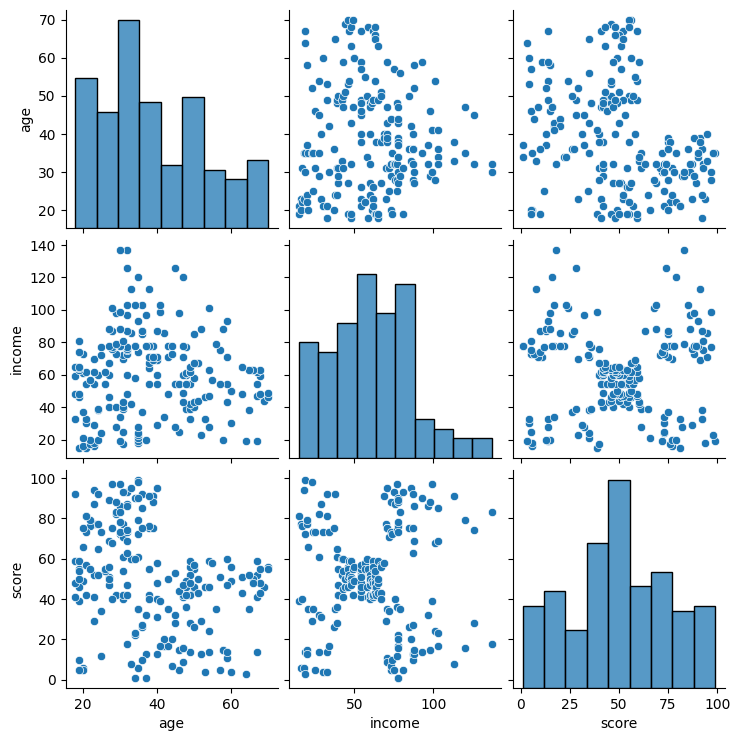

In [9]:
seaborn.pairplot (df[['age', 'income','score']])

In [10]:
import sklearn.cluster as cluster
kmeans = cluster.KMeans(n_clusters = 5)

In [11]:
kmeans = kmeans.fit(df[['score','income']])

In [12]:
#Finding out the centroids
kmeans.cluster_centers_

array([[82.12820513, 86.53846154],
       [49.51851852, 55.2962963 ],
       [79.36363636, 25.72727273],
       [17.11428571, 88.2       ],
       [20.91304348, 26.30434783]])

In [13]:
kmeans = kmeans.fit(df[['income','score']])

In [14]:
kmeans.cluster_centers_

array([[26.30434783, 20.91304348],
       [86.53846154, 82.12820513],
       [88.2       , 17.11428571],
       [25.72727273, 79.36363636],
       [55.2962963 , 49.51851852]])

In [15]:
df['income_clusters'] = kmeans.labels_

In [16]:
df

,CustomerID,gender,age,income,score,income_clusters
0,1,Male,19,15,39,0
1,2,Male,21,15,81,3
2,3,Female,20,16,6,0
3,4,Female,23,16,77,3
4,5,Female,31,17,40,0
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,2
197,198,Male,32,126,74,1
198,199,Male,32,137,18,2


In [17]:
# counting in which cluster how many values
df['income_clusters'].value_counts()

income_clusters
4    81
1    39
2    35
0    23
3    22
Name: count, dtype: int64

<Axes: xlabel='score', ylabel='income'>

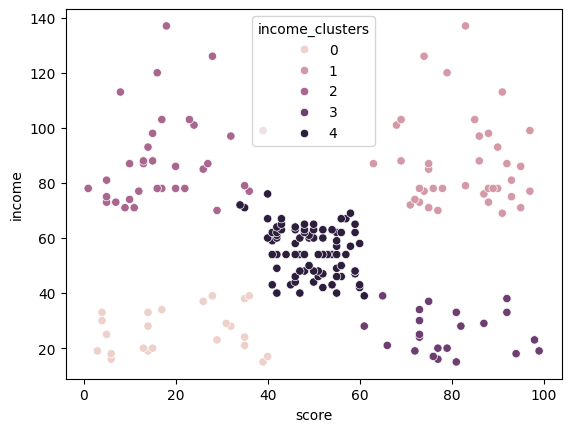

In [18]:
seaborn.scatterplot(x= 'score', y = 'income', hue= 'income_clusters', data= df)

<Axes: xlabel='income', ylabel='score'>

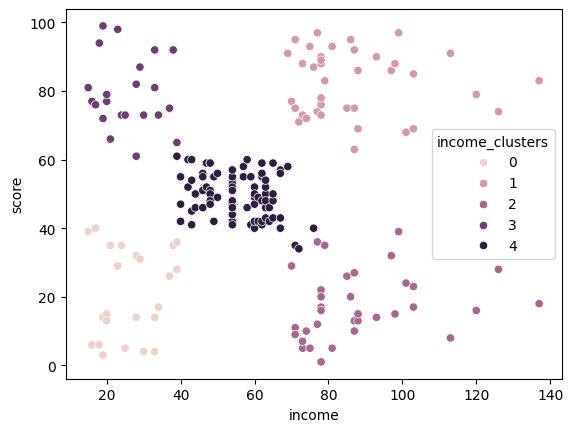

In [19]:
seaborn.scatterplot(x= 'income', y = 'score', hue= 'income_clusters', data= df)

In [20]:
#trying with 2 clusters
kmeans = cluster.KMeans(n_clusters = 2)

In [21]:
kmeans = kmeans.fit(df[['age','score']])

In [22]:
kmeans.cluster_centers_

array([[46.16521739, 32.88695652],
       [28.95294118, 73.62352941]])

In [23]:
df['age_clusters'] = kmeans.labels_

In [24]:
df

,CustomerID,gender,age,income,score,income_clusters,age_clusters
0,1,Male,19,15,39,0,0
1,2,Male,21,15,81,3,1
2,3,Female,20,16,6,0,0
3,4,Female,23,16,77,3,1
4,5,Female,31,17,40,0,0
...,...,...,...,...,...,...,...
195,196,Female,35,120,79,1,1
196,197,Female,45,126,28,2,0
197,198,Male,32,126,74,1,1
198,199,Male,32,137,18,2,0


In [25]:
df['age_clusters'].value_counts()

age_clusters
0    115
1     85
Name: count, dtype: int64

In [26]:
df

,CustomerID,gender,age,income,score,income_clusters,age_clusters
0,1,Male,19,15,39,0,0
1,2,Male,21,15,81,3,1
2,3,Female,20,16,6,0,0
3,4,Female,23,16,77,3,1
4,5,Female,31,17,40,0,0
...,...,...,...,...,...,...,...
195,196,Female,35,120,79,1,1
196,197,Female,45,126,28,2,0
197,198,Male,32,126,74,1,1
198,199,Male,32,137,18,2,0


<Axes: xlabel='age', ylabel='score'>

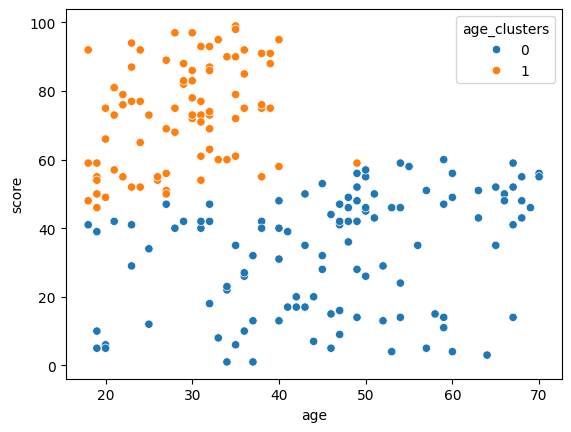

In [27]:
seaborn.scatterplot(x= 'age', y = 'score', hue= 'age_clusters', data= df)

#  Applying Elbow methods

In [28]:
#from sklearn.cluster import kMeans
from sklearn.cluster import KMeans

In [29]:
# to calculate 12 clusters
k_range = range(1,12)
wcss = []

In [30]:
# implementing for loop for 12 clusters to find out wcss value for each cluster
# adding wcss values of clusters in wcss array

for k in k_range:
    km= KMeans(n_clusters =k)
    km.fit(df[['income','score']])
    wcss.append (km.inertia_)

##  Showing the values of wcss

In [31]:
wcss

[269981.28,
 186362.95600651752,
 106348.37306211116,
 73880.64496247197,
 44454.47647967974,
 38797.9027638142,
 31600.209115340018,
 25056.895153616184,
 23311.584210674235,
 21797.817560054325,
 18092.765869660056]

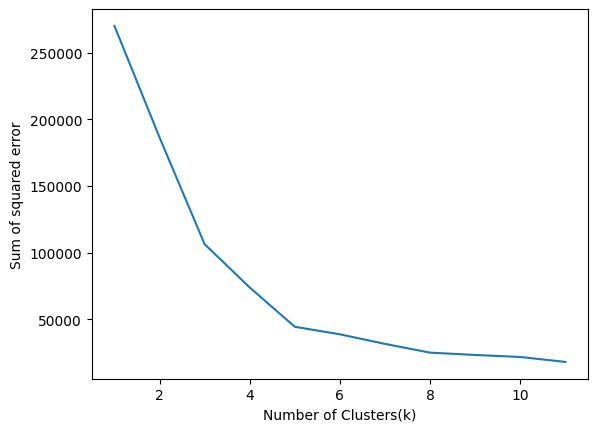

In [32]:
plt.xlabel ('Number of Clusters(k)')
plt.ylabel ('Sum of squared error')
plt.plot (k_range , wcss)